Compute velocity and define time slices

In [1]:
from anndata import AnnData 
import cellrank as cr
import math
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from numpy.linalg import pinv
import ot 
import pandas as pd
import random
import seaborn as sbn
import scipy
import anndata as ad
import scanpy as sc
import scFates as scf
import scipy.stats as stats
from scipy import sparse
from scipy.stats import wasserstein_distance
from scipy.special import gammaln
from scipy.cluster.hierarchy import linkage, to_tree, dendrogram
from scipy.spatial.distance import pdist
import scvelo as scv

/Users/olivier_2/carda_venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# Hyperparameter values
SFT= 12.5 # time scale factor
s=50 # point size for scatter plots

1. Load the data

In [3]:
path="/Users/olivier_2/Documents/En_cours/Labo/Manipes/OG3700/"
adata = ad.read_h5ad(path+'adata_3700_1.h5ad')

2. Compute RNA velocity

In [4]:
scv.pp.filter_and_normalize(adata)
scv.pp.moments(adata)
scv.tl.velocity(adata, mode='stochastic')
scv.tl.velocity_graph(adata, show_progress_bar=False,n_jobs=8)
scv.tl.rank_velocity_genes(adata, groupby="louvain")
scv.tl.terminal_states(adata, vkey='velocity')
scv.tl.velocity_pseudotime(adata)
scv.tl.recover_dynamics(adata, show_progress_bar=False,n_jobs=8)
scv.tl.latent_time(adata)
scv.tl.score_genes_cell_cycle(adata)

Normalized count data: spliced, unspliced.


/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/var/folders/nc/l51kf37s6gnb09vx27y1q8q00000gq/T/ipykernel_66229/1727822271.py:2: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata)
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


Logarithmized X.
computing neighbors
    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:04) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 8/14 cores)


/Users/olivier_2/carda_venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package 

    finished (0:00:04) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
ranking velocity genes


/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/tools/utils.py:463: DeprecationWarning: Please import `rankdata` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import rankdata


    finished (0:00:15) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
recovering dynamics (using 8/14 cores)
    finished (0:00:29) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing latent time using root_cells as prior
    finished (0:00:02) --> added 
    'latent_time', shared time (adata.obs)
calculating cell cycle phase
-->     'S_score' and 'G2M_score', scores of cell cycle phases (adata.obs)


/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scanpy/tools/_score_genes.py:241: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  r_genes: pd.Index[str] = obs_cut[(obs_cut == cut) & ~keep_ctrl_in_obs_cut].index
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scanpy/tools/_score_genes.py:241: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  r_genes: pd.Index[str] = obs_cut[(obs_cut == cut) & ~

3. Plot some output

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.

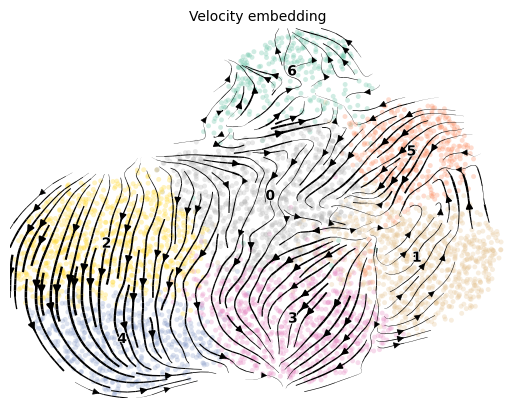

In [5]:
scv.pl.velocity_embedding_stream(
    adata,
    basis='X_umap',
    color='leiden',  
    show=True, title="Velocity embedding", 
    s=s
)

/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.

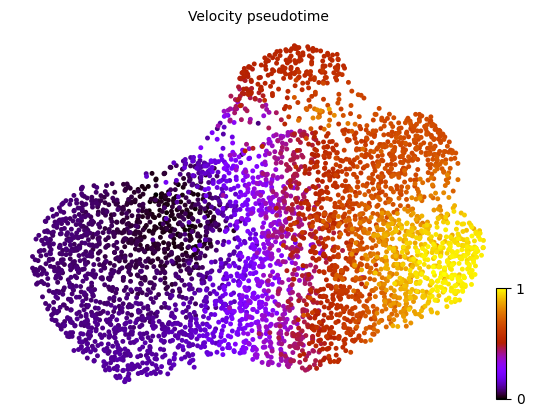

/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.

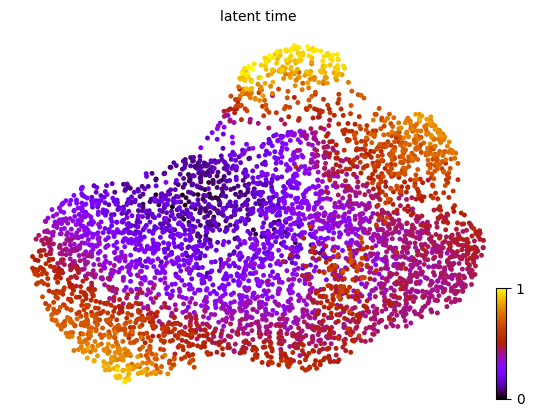

In [6]:
# Plot velocity pseudotime
scv.pl.scatter(adata, 
    color=["velocity_pseudotime"],
    show=True,
    title="Velocity pseudotime",
    color_map='gnuplot',
    s=s)

# Plot latent pseudotime
scv.pl.scatter(adata, 
    color=["latent_time"],
    show=True,
    title="latent_time",
    color_map='gnuplot',
    s=s)

4. Compute CellRank

In [7]:
vk = cr.kernels.VelocityKernel(adata)
vk.compute_transition_matrix()
g = cr.estimators.GPCCA(vk)
g.fit(cluster_key="louvain", n_states=2)
g.predict_initial_states(allow_overlap=True)
g.predict_terminal_states(allow_overlap=True)

  0%|          | 0/4345 [00:00<?, ?cell/s]

  0%|          | 0/4345 [00:00<?, ?cell/s]

GPCCA[kernel=VelocityKernel[n=4345], initial_states=['0'], terminal_states=['0', '5']]

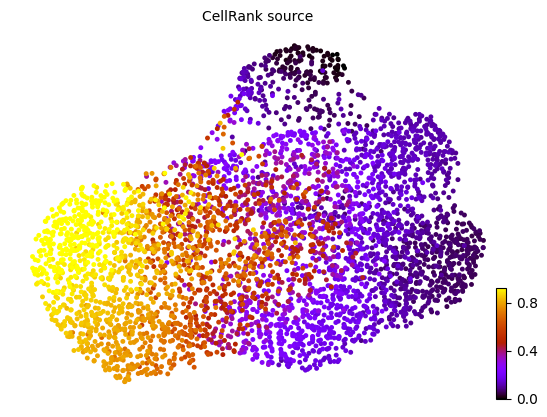

In [8]:
g.plot_macrostates(which="initial", 
		legend_loc="right", 
		s=s,
		discrete=False,    
		show=True,
        cmap='gnuplot',
        title="CellRank source"
)	

5. Compute scFates 

In [9]:
scf.tl.cellrank_to_tree(adata,time="init_states_fwd_probs",Nodes=150,seed=42)

Converting CellRank results to a principal tree --> with .obsm['X_fates'], created by combining:
    .obsm[term_states_fwd_memberships][:,0] and adata.obs['init_states_fwd_probs']

inferring a principal tree --> parameters used 
    150 principal points, sigma = 0.1, lambda = 100, metric = euclidean
    fitting:  38%|███▊      | 19/50 [00:00<00:00, 31.91it/s]
    converged
    finished (0:00:00) --> added 
    .uns['ppt'], dictionnary containing inferred tree.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'] coordinates of principal points in representation space.

finished (0:01:25)     .obsm['X_fates'] representation used for fitting the tree.
    .uns['graph']['pp_info'].time has been updated with init_states_fwd_probs
    .uns['graph']['pp_seg'].d has been updated with init_states_fwd_probs


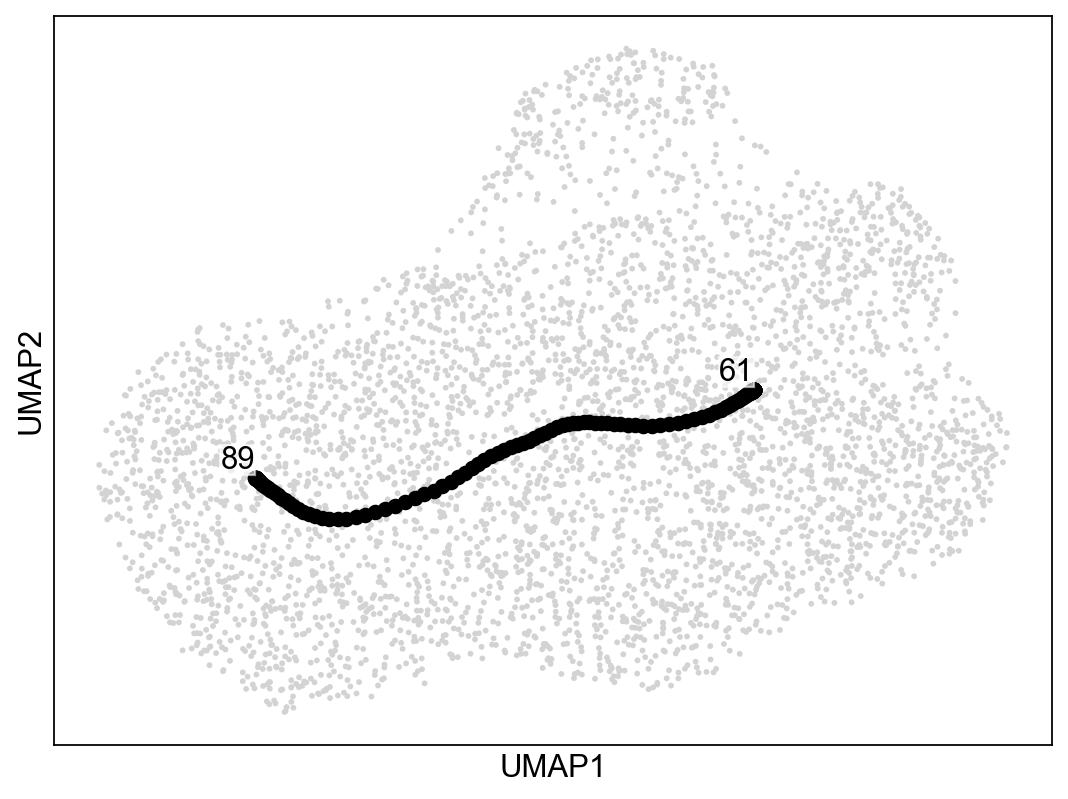

In [10]:
sc.set_figure_params(figsize=(8,6))
scf.pl.graph(adata)

In [11]:
scf.tl.root(adata,89)
scf.tl.pseudotime(adata,n_jobs=10,n_map=100,seed=42)

node 89 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.
projecting cells onto the principal graph
    mappings:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/olivier_2/carda_venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


    mappings:   2%|▏         | 2/100 [00:05<04:49,  2.96s/it]

/Users/olivier_2/carda_venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


    mappings:  10%|█         | 10/100 [00:07<01:07,  1.34it/s]

...

    mappings:  16%|█▌        | 16/100 [00:13<01:10,  1.19it/s]

/Users/olivier_2/carda_venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


    mappings:  21%|██        | 21/100 [00:14<00:54,  1.46it/s]

/Users/olivier_2/carda_venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


    mappings: 100%|██████████| 100/100 [00:23<00:00,  4.31it/s]
    finished (0:00:23) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scFates/plot/milestones.py:83: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


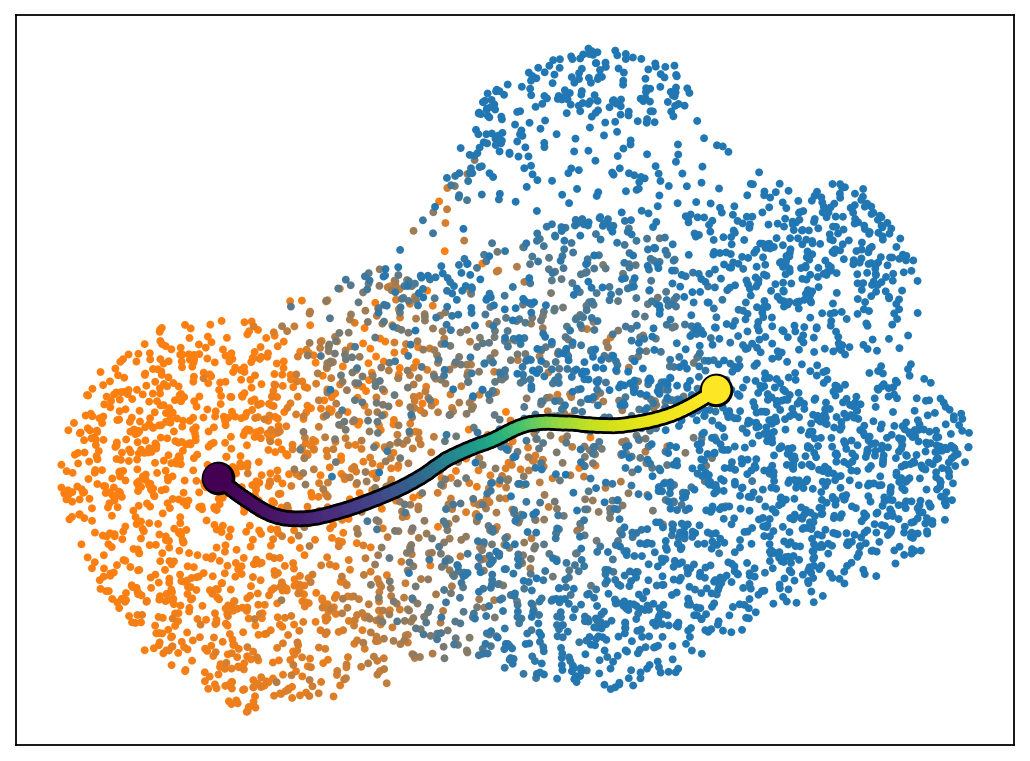

In [12]:
sc.set_figure_params(figsize=(8,6))

scf.pl.trajectory(adata,
                  color_cells="milestones",
                  cmap="rainbow", s=s, 
                  save="velocity_pseudotime.svg")

6. Define "time"

In [13]:
# Time will be defined by cutting the 'velocity_pseudotime' column into 5 equal segments
pseudotime_col = 'velocity_pseudotime' 
target_col = 'time'

# 1. Calculate thresholds for 5 equal segments
segments, bins = pd.qcut(
    adata.obs[pseudotime_col], 
    q=5, 
    retbins=True, 
    labels=False, 
    duplicates='drop' # Handles cases with too many identical values (plateaus)
)

# Change numeric labels to 't1', 't2', ..., 't5'
adata.obs['time'] = ['t' + str(i + 1) for i in segments]

adata.obs['time'] = pd.Categorical(
    adata.obs['time'], 
    categories=['t1', 't2', 't3', 't4', 't5'], 
    ordered=True
)

mapping_values = {
    't1': 0 * SFT,
    't2': 1 * SFT,
    't3': 2 * SFT,
    't4': 3 * SFT,
    't5': 4 * SFT
}

# 2. Apply this mapping to the 'time' column
adata.obs['time'] = adata.obs['time'].map(mapping_values)

/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/olivier_2/carda_venv/lib/python3.12/site-packages/scvelo/plotting/utils.

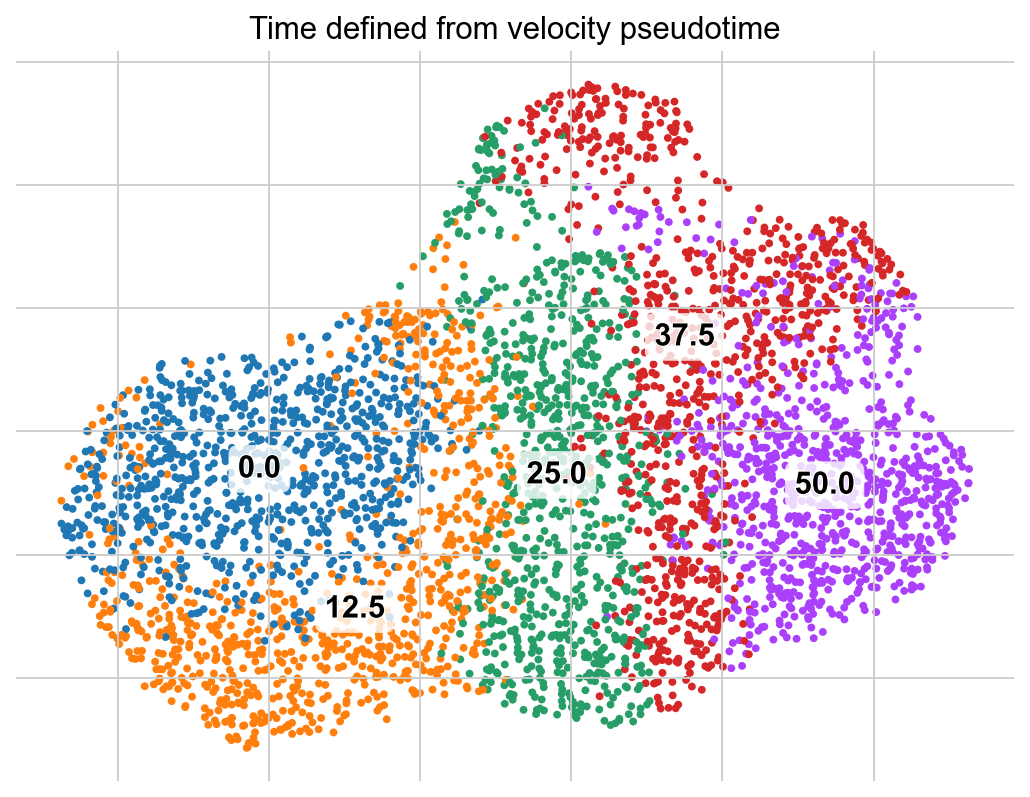

In [14]:
scv.pl.scatter(adata, 
    color="time",
    show=False,
    title="Time defined from velocity_pseudotime",
    color_map='gnuplot',
    s=s)

ax = plt.gca()
for text in ax.texts:
    text.set_bbox(dict(
        facecolor='white',      
        edgecolor='none',       
        alpha=0.8,              
        boxstyle='round,pad=0.3'
    ))
    text.set_color('black')   

plt.show()

7. Save

In [15]:
adata.write_h5ad('adata_3700_2.h5ad')